In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

In [5]:
with open('../../milestone3/trace_delta_census.pkl', 'rb') as f:
    trace_delta_census = pickle.load(f)

/Users/kennygu/school/phd/s26/.venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [8]:
trace_delta_census['trace']['posterior_predictive']

<xarray.Dataset> Size: 16MB
Dimensions:      (chain: 4, draw: 1000, y_obs_dim_0: 500)
Coordinates:
  * chain        (chain) int64 32B 0 1 2 3
  * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
  * y_obs_dim_0  (y_obs_dim_0) int64 4kB 0 1 2 3 4 5 ... 494 495 496 497 498 499
Data variables:
    y_obs        (chain, draw, y_obs_dim_0) float64 16MB -2.003 -6.099 ... 2.073
Attributes:
    created_at:                 2026-05-04T19:57:32.748656+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.5

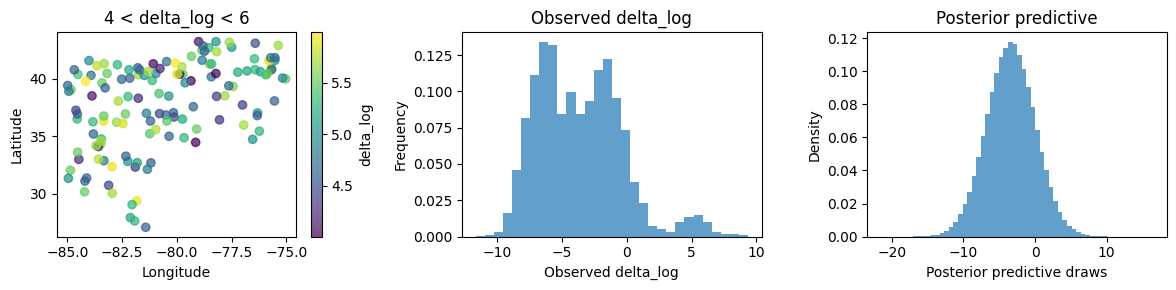

In [33]:
# posterior predictive draws of delta_log
y_rep = trace_delta_census['trace'].posterior_predictive["y_obs"]
y_rep_flat = y_rep.stack(sample=("chain", "draw")).values.ravel()
agg = pickle.load(open('../../milestone3/delta_log.pkl', 'rb'))
deltas = agg['delta_log'].values

# plot lat and lng of obs with delta_log > 4
obs_indices = np.where(np.logical_and(deltas > 4, deltas < 6))[0]
obs_data = pd.DataFrame({
    "lat": agg['lat'][obs_indices],
    "lng": agg['lng'][obs_indices],
    "delta_log": deltas[obs_indices]
})
# plt.figure(figsize=(6, 6))
# plt.scatter(obs_data['lng'], obs_data['lat'], c=obs_data['delta_log'], cmap='viridis', alpha=0.7)
# plt.colorbar(label='delta_log')
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")

plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.scatter(obs_data['lng'], obs_data['lat'], c=obs_data['delta_log'], cmap='viridis', alpha=0.7)
plt.colorbar(label='delta_log')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("4 < delta_log < 6")

plt.subplot(1, 3, 2)
plt.hist(deltas, bins=30, alpha=0.7, density=True, label='Observed delta_log')
plt.xlabel("Observed delta_log")
plt.ylabel("Frequency")
plt.title("Observed delta_log")

plt.subplot(1, 3, 3)
plt.hist(y_rep_flat, bins=60, density=True, alpha=0.7, label="Posterior predictive draws")
plt.xlabel("Posterior predictive draws")
plt.ylabel("Density")
plt.title("Posterior predictive")
plt.tight_layout()
plt.savefig("posterior_predictive_check.png")

Text(0, 0.5, 'Latitude')

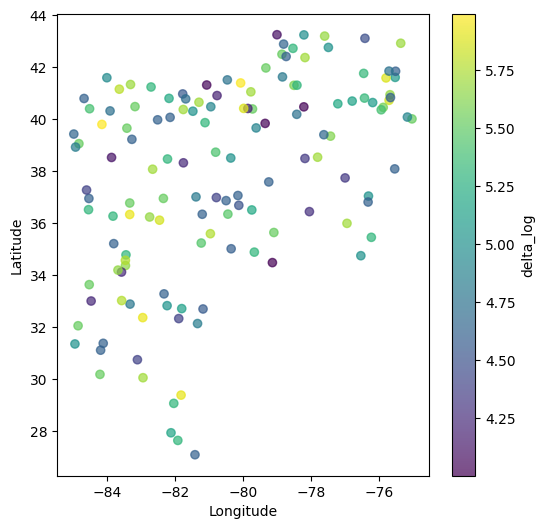